In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
df=pd.read_csv('google_trends_business_ideas.csv')

In [20]:
df.head()

,date,Interest,Search_Term
0,2019-01-01,7,AI business ideas
1,2019-02-01,4,AI business ideas
2,2019-03-01,6,AI business ideas
3,2019-04-01,7,AI business ideas
4,2019-05-01,5,AI business ideas


In [21]:
df.tail()

,date,Interest,Search_Term
571,2024-08-01,88,Mobile app development
572,2024-09-01,87,Mobile app development
573,2024-10-01,85,Mobile app development
574,2024-11-01,78,Mobile app development
575,2024-12-01,81,Mobile app development


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         576 non-null    object
 1   Interest     576 non-null    int64 
 2   Search_Term  576 non-null    object
dtypes: int64(1), object(2)
memory usage: 13.6+ KB


In [23]:
df.columns

Index(['date', 'Interest', 'Search_Term'], dtype='object')

In [24]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [25]:
avg_interest = df.groupby('Search_Term')['Interest'].mean().sort_values(ascending=False)
print("\nAverage Interest by Search Term")
print(avg_interest)


Average Interest by Search Term
Search_Term
Virtual assistant services       77.375000
Mobile app development           76.986111
Digital marketing agency         66.277778
E-commerce startup               63.291667
Subscription box business        62.277778
Dropshipping business            52.055556
Sustainable products business    43.347222
AI business ideas                31.430556
Name: Interest, dtype: float64


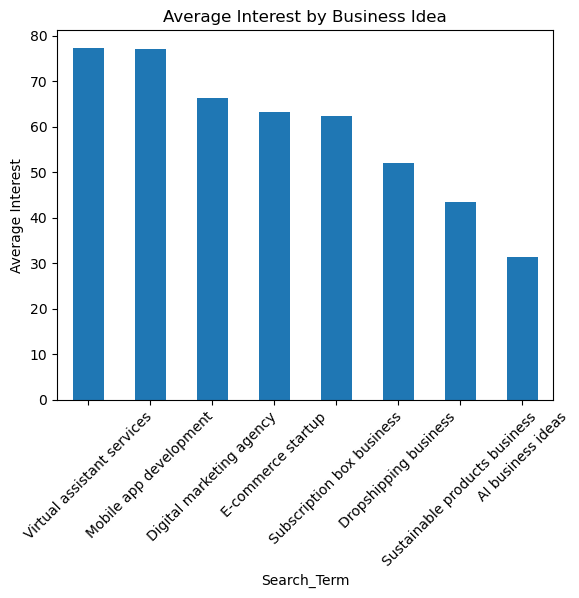

In [26]:
plt.figure()
avg_interest.plot(kind='bar')
plt.title("Average Interest by Business Idea")
plt.ylabel("Average Interest")
plt.xticks(rotation=45)
plt.show()

In [27]:
growth = df.groupby('Search_Term').apply(
       lambda x: x.iloc[-1]['Interest'] - x.iloc[0]['Interest']
).sort_values(ascending=False)
print("\nGrowth (Last - First)")
print(growth)


Growth (Last - First)
Search_Term
AI business ideas                83
Digital marketing agency         57
E-commerce startup               47
Sustainable products business    45
Dropshipping business            38
Virtual assistant services       24
Mobile app development           21
Subscription box business       -41
dtype: int64


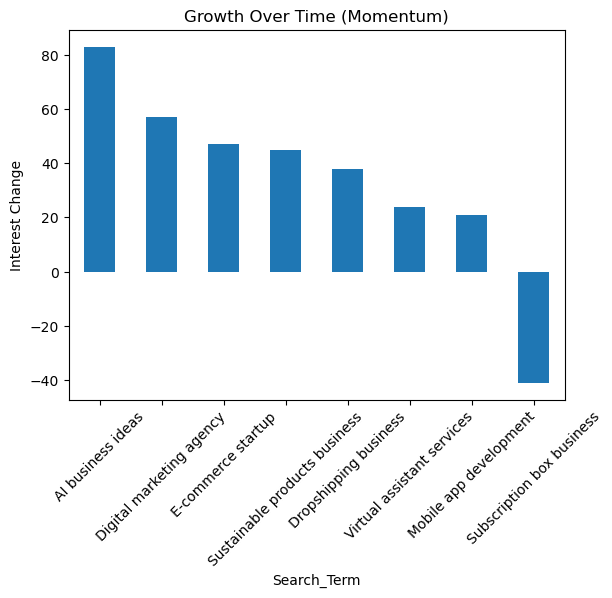

In [28]:
plt.figure()
growth.plot(kind='bar')
plt.title("Growth Over Time (Momentum)")
plt.ylabel("Interest Change")
plt.xticks(rotation=45)
plt.show()

In [29]:
volatility = df.groupby('Search_Term')['Interest'].std().sort_values(ascending=False)
print("\nVolatility (Standard Deviation)")
print(volatility)


Volatility (Standard Deviation)
Search_Term
AI business ideas                35.183954
Sustainable products business    23.402877
Dropshipping business            21.852830
E-commerce startup               17.272821
Digital marketing agency         17.150717
Subscription box business        15.050359
Virtual assistant services       12.819920
Mobile app development            9.725085
Name: Interest, dtype: float64


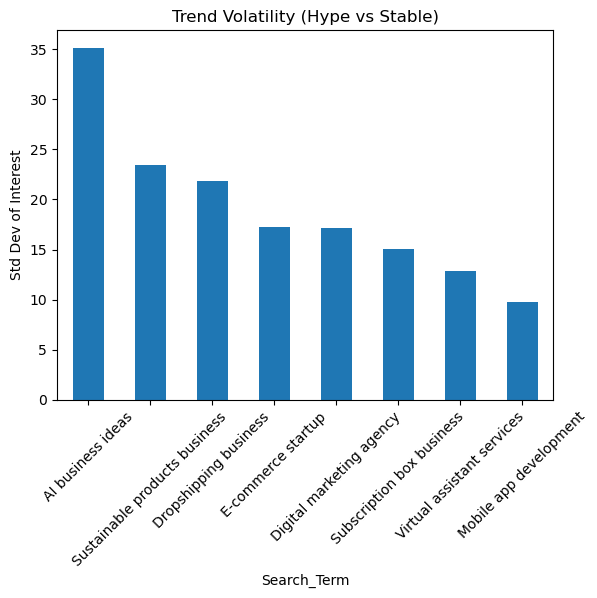

In [30]:
plt.figure()
volatility.plot(kind='bar')
plt.title("Trend Volatility (Hype vs Stable)")
plt.ylabel("Std Dev of Interest")
plt.xticks(rotation=45)
plt.show()

In [31]:
monthly = df.copy()
monthly['month'] = monthly['date'].dt.month
seasonality = monthly.groupby(['month', 'Search_Term'])['Interest'].mean().unstack()
print(seasonality)

Search_Term  AI business ideas  Digital marketing agency  \
month                                                      
1                    28.333333                 61.333333   
2                    31.666667                 61.500000   
3                    27.833333                 61.833333   
4                    29.333333                 61.166667   
5                    29.333333                 62.333333   
6                    30.000000                 66.500000   
7                    30.500000                 69.833333   
8                    33.333333                 70.000000   
9                    34.166667                 70.500000   
10                   33.666667                 69.666667   
11                   34.500000                 69.166667   
12                   34.500000                 71.500000   

Search_Term  Dropshipping business  E-commerce startup  \
month                                                    
1                        57.666667         

<Figure size 640x480 with 0 Axes>

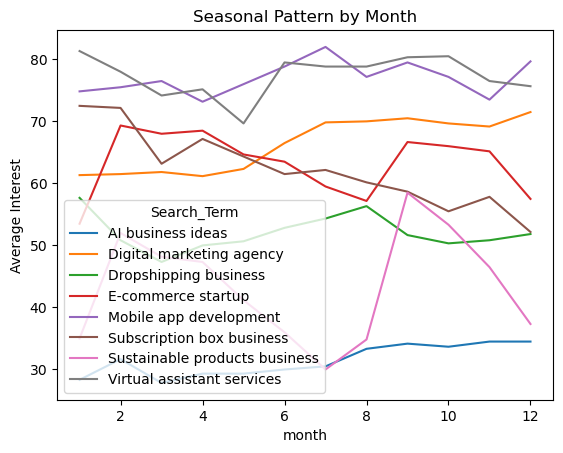

In [32]:
plt.figure();
seasonality.plot();
plt.title("Seasonal Pattern by Month");
plt.ylabel("Average Interest");
plt.show();

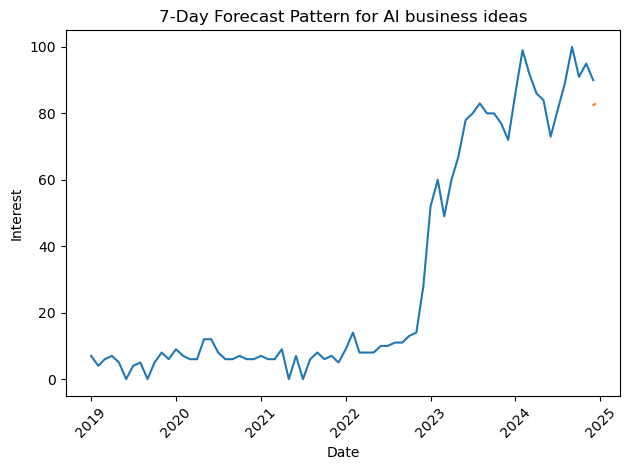

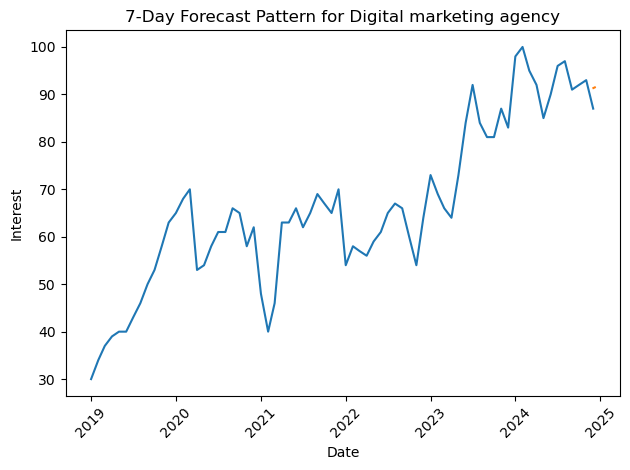

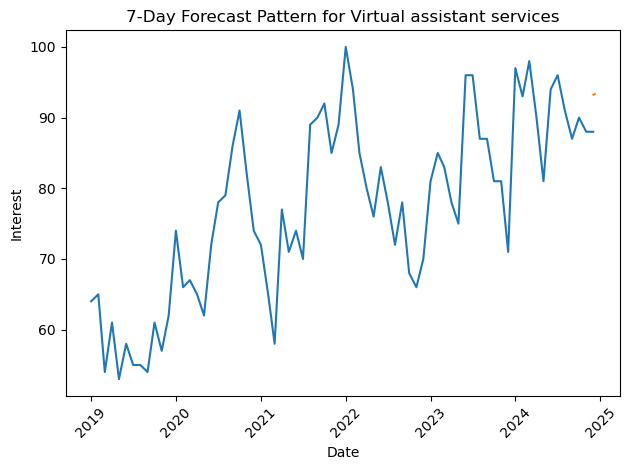

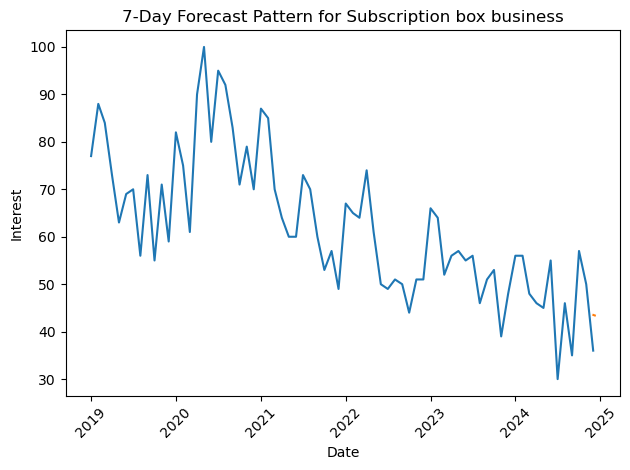

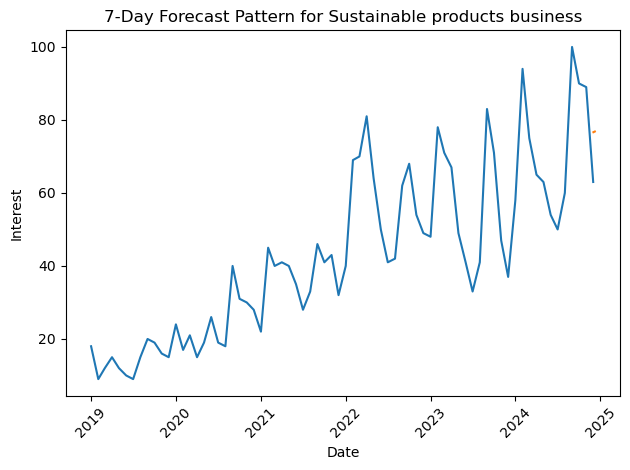

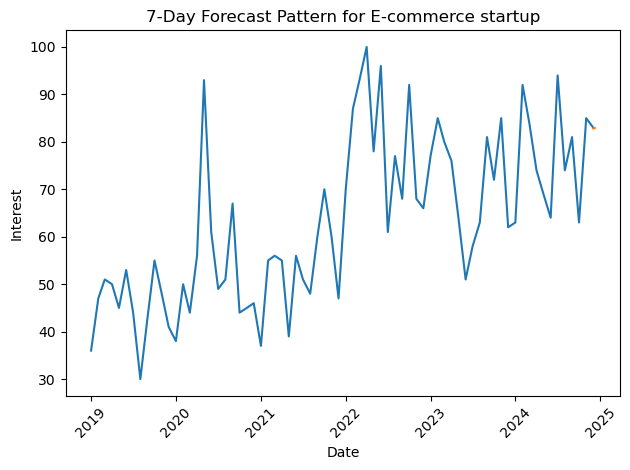

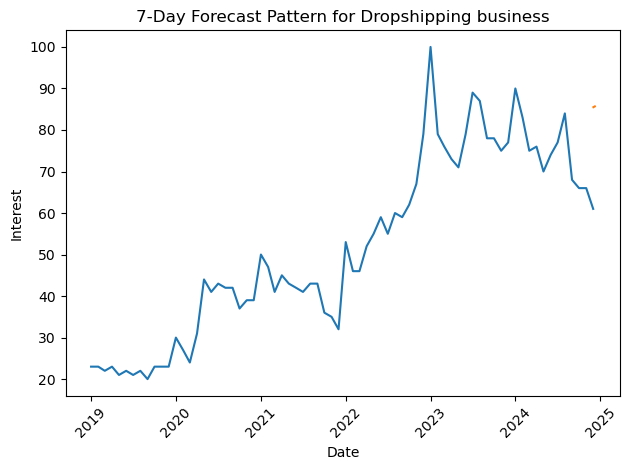

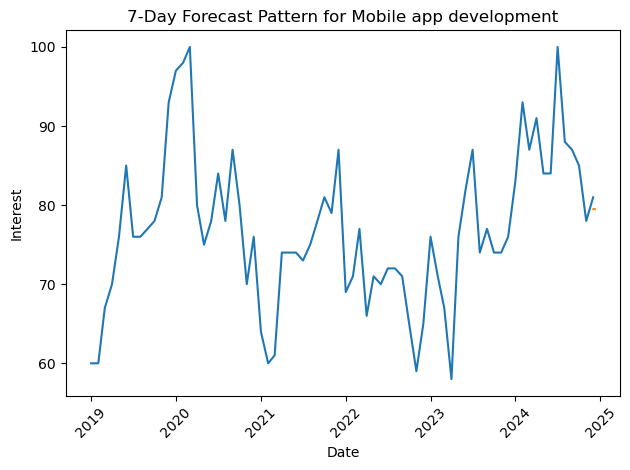

In [33]:
forecast_summary = {}
for term in df['Search_Term'].unique():
    term_df = df[df['Search_Term'] == term].copy()
    term_df = term_df.sort_values('date')
    term_df['date_num'] = term_df['date'].map(pd.Timestamp.toordinal)
    X = term_df['date_num'].values
    y = term_df['Interest'].values
    coeffs = np.polyfit(X, y, 1)
    trend_line = np.poly1d(coeffs)
    last_date = term_df['date'].max()
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=7)
    future_nums = future_dates.map(pd.Timestamp.toordinal).values
    forecast_values = trend_line(future_nums)
    forecast_df = pd.DataFrame({
        'date': future_dates,
        'Forecasted_Interest': forecast_values
    })
    forecast_summary[term] = forecast_df

    plt.figure()
    plt.plot(term_df['date'], term_df['Interest'])
    plt.plot(future_dates, forecast_values)
    plt.title(f"7-Day Forecast Pattern for {term}")
    plt.xlabel("Date")
    plt.ylabel("Interest")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [34]:
for term, fdf in forecast_summary.items():
    print(f"\nForecast for {term}:")
    print(fdf)


Forecast for AI business ideas:
        date  Forecasted_Interest
0 2024-12-02            82.513559
1 2024-12-03            82.560768
2 2024-12-04            82.607977
3 2024-12-05            82.655187
4 2024-12-06            82.702396
5 2024-12-07            82.749605
6 2024-12-08            82.796814

Forecast for Digital marketing agency:
        date  Forecasted_Interest
0 2024-12-02            91.341683
1 2024-12-03            91.364846
2 2024-12-04            91.388009
3 2024-12-05            91.411173
4 2024-12-06            91.434336
5 2024-12-07            91.457499
6 2024-12-08            91.480662

Forecast for Virtual assistant services:
        date  Forecasted_Interest
0 2024-12-02            93.247714
1 2024-12-03            93.262383
2 2024-12-04            93.277052
3 2024-12-05            93.291721
4 2024-12-06            93.306390
5 2024-12-07            93.321059
6 2024-12-08            93.335728

Forecast for Subscription box business:
        date  Forecasted_Int